In [1]:
import cv2
import numpy as np
import toml
import os
import msgpack as mp
import msgpack_numpy as mpn
import matplotlib.pyplot as plt
from cv2 import aruco
from tqdm import tqdm
import polars as pl
import sys
sys.path.append('..')
from pd_support import *

from scipy.spatial.transform import Rotation as R

Loading camera calibration

In [2]:
# data = toml.load("../undistort_fisheye_mono_1200_800.toml")
# data = toml.load("../undistort_best.toml")
# data = toml.load("../calib_mono_1200_800.toml")
# data = toml.load("../calib_undistort_aruco.toml")
# data = toml.load("../calib_mono_faith.toml")
data = toml.load("calib_mono_faith3D.toml")
camera_matrix = np.array(data["calibration"]["camera_matrix"]).reshape(3, 3)
dist_coeff = np.array(data["calibration"]["dist_coeffs"])

_parent_dir = os.path.join(os.path.dirname(os.getcwd()),'..', "example_dataset")
# _parent_dir = r"E:\CMC\pyprojects\DeepVision\recorded_data\five_marker_validation"
_folder_name = "mono2_3d_trial0"
# _folder_name = "mono3d_angle_t0"
_base_pth = os.path.join(_parent_dir, "recordings", _folder_name)

In [3]:
_parent_dir

'e:\\CMC\\pyprojects\\programs_rpi\\NOARK_backbone\\notebooks\\..\\example_dataset'

In [4]:
camera_matrix

array([[739.68290431,   0.        , 618.64382828],
       [  0.        , 750.98353839, 383.58331383],
       [  0.        ,   0.        ,   1.        ]])

In [5]:
ARUCO_PARAMETERS = aruco.DetectorParameters()
ARUCO_DICT = aruco.getPredefinedDictionary(aruco.DICT_APRILTAG_36H11)
detector = aruco.ArucoDetector(ARUCO_DICT, ARUCO_PARAMETERS)
markerLength = 0.05
markerSeperation = 0.01

default_ids = [4, 8, 12, 14, 20]

board = aruco.GridBoard(
    size=[1, 1],
    markerLength=markerLength,
    markerSeparation=markerSeperation,
    dictionary=ARUCO_DICT,
)

In [6]:
def estimate_pose_single_markers(
    corners, marker_size, camera_matrix, distortion_coefficients
):
    marker_points = np.array(
        [
            [-marker_size / 2, marker_size / 2, 0],
            [marker_size / 2, marker_size / 2, 0],
            [marker_size / 2, -marker_size / 2, 0],
            [-marker_size / 2, -marker_size / 2, 0],
        ],
        dtype=np.float32,
    )
    rvecs = []
    tvecs = []
    for corner in corners:
        _, r, t = cv2.solvePnP(
            marker_points,
            corner,
            camera_matrix,
            distortion_coefficients,
            True,
            flags=cv2.SOLVEPNP_IPPE_SQUARE,
        )
        if r is not None and t is not None:
            r = np.array(r).reshape(1, 3).tolist()
            t = np.array(t).reshape(1, 3).tolist()
            rvecs.append(r)
            tvecs.append(t)
    return np.array(rvecs, dtype=np.float32), np.array(tvecs, dtype=np.float32)

In [7]:
# data = toml.load("../undistort_best.toml")
# data = toml.load("../calib_mono_1200_800.toml")
# data = toml.load("../calib_undistort_aruco.toml")
# data = toml.load("../calib_mono_faith3D.toml")
_camera_matrix = np.array(data["calibration"]["camera_matrix"]).reshape(3, 3)
_dist_coeff = np.array(data["calibration"]["dist_coeffs"])

In [8]:
rvecs, tvecs = [], []
with open(os.path.join(_base_pth, "webcam_color.msgpack"), "rb") as _f:
    unpacker = mp.Unpacker(_f, object_hook=mpn.decode)
    img_size = next(unpacker)
    for _frame in tqdm(unpacker):
        corners, ids = _frame
        # if corners:
        #     _corners = cv2.undistortImagePoints(np.array(corners[0]), camera_matrix, dist_coeff)
        # else:
        #     _corners = None

        if (ids is not None and len(ids) > 0) and all(
            item in default_ids for item in np.array(ids)
        ):
            rotation_vectors, translation_vectors = estimate_pose_single_markers(
                corners=corners,
                marker_size=0.05,
                camera_matrix=_camera_matrix,
                distortion_coefficients=_dist_coeff,
            )
            rvecs.append(rotation_vectors[0][0])
            tvecs.append(translation_vectors[0][0])

        else:
            rvecs.append(np.array([np.nan, np.nan, np.nan]))
            tvecs.append(np.array([np.nan, np.nan, np.nan]))

timestamp = []
sync = []

with open(os.path.join(_base_pth, "webcam_timestamp.msgpack"), "rb") as _f:
    unpacker = mp.Unpacker(_f, object_hook=mpn.decode)
    for _p in unpacker:
        sync.append(_p[0])
        timestamp.append(_p[1])
tvecs = np.array(tvecs)
rvecs = np.array(rvecs)
sync = np.array(sync).astype(bool)

1636it [00:00, 23449.80it/s]


In [9]:
ar_dict = {
    "time": timestamp,
    "sync": sync,
    "x": tvecs[:, 0],
    "y": tvecs[:, 1],
    "z": tvecs[:, 2],
    "rx": rvecs[:, 0],
    "ry": rvecs[:, 1],
    "rz": rvecs[:, 2],
}
ar_df = pl.from_dict(ar_dict)
if type(ar_df["time"][0]) is not datetime:
    ar_df = ar_df.with_columns(pl.col("time").str.to_datetime())

In [10]:
pulse_sweep = False
for idx, val in enumerate(ar_df["sync"]):
    if val == True and not pulse_sweep:
        start_pulse = idx
        pulse_sweep = True
    if val == False and pulse_sweep:
        end_pulse = idx
        break
ar_df = ar_df[start_pulse:end_pulse]

In [11]:
mocap_df, st_time = read_rigid_body_csv(os.path.join(_base_pth, f"{_folder_name}.csv"))
# mocap_df, st_time = read_rigid_body_csv(r"E:\CMC\pyprojects\DeepVision\recorded_data\five_marker_validation\mocap\coord_3d.csv")
mocap_df = add_datetime_col(mocap_df, st_time, "seconds")
mocap_df = pl.from_pandas(mocap_df)

e:\CMC\pyprojects\programs_rpi\NOARK_backbone\notebooks\analysis\..\pd_support.py:326: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  _rb_df = _rb_df.apply(pd.to_numeric, errors="ignore")


In [12]:
tr = get_rb_marker_name(1)
tl = get_rb_marker_name(4)
br = get_rb_marker_name(5)
bl = get_rb_marker_name(6)

In [13]:
_time_diff = ar_df["time"][0] - mocap_df["time"][0]

ar_df = ar_df.with_columns([(pl.col("time") - _time_diff).alias("time")])

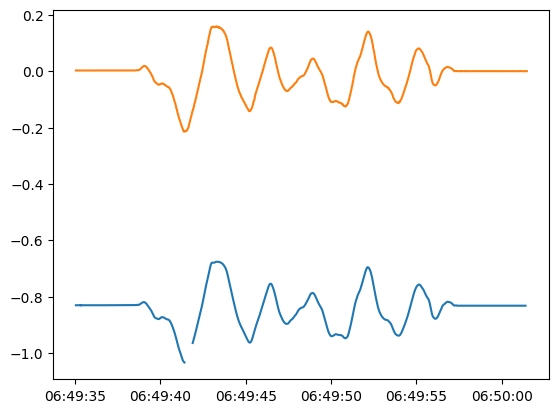

In [14]:
plt.plot(mocap_df["time"], mocap_df[tr["x"]])
plt.plot(ar_df["time"], ar_df["x"])

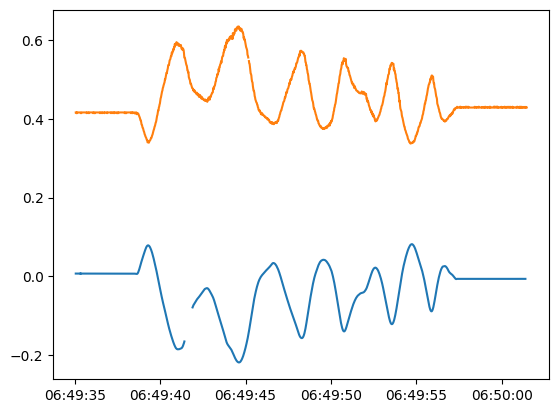

In [15]:
plt.plot(mocap_df["time"], mocap_df[tr["z"]])
plt.plot(ar_df["time"], ar_df["z"])

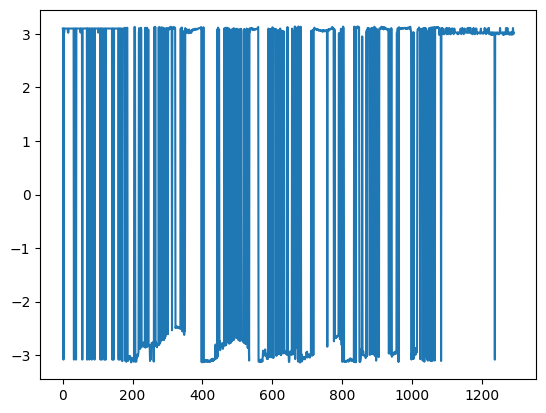

In [16]:
plt.plot(ar_df["rx"])

In [17]:
t_dict = {"x": [], "y": [], "z": []}
rmat = cv2.Rodrigues(ar_df[["rx", "ry", "rz"]][1].to_numpy())[0]

for i in range(len(ar_df["time"])):
    tvec = rmat.T @ (
        ar_df[["x", "y", "z"]][i].to_numpy().reshape(3, 1)
        - ar_df[["x", "y", "z"]][1].to_numpy().reshape(3, 1)
    )
    tvec = tvec.T[0]
    t_dict["x"].append(tvec[0])
    t_dict["y"].append(tvec[1])
    t_dict["z"].append(tvec[2])

In [18]:
tvec

array([-0.00182271,  0.00048759, -0.01253416])

In [19]:
mocap_mean = {"x": [], "y": [], "z": []}
mocap_mean["x"] = mocap_df[[tr["x"], tl["x"], br["x"], bl["x"]]].to_numpy().mean(axis=1)
mocap_mean["y"] = mocap_df[[tr["y"], tl["y"], br["y"], bl["y"]]].to_numpy().mean(axis=1)
mocap_mean["z"] = mocap_df[[tr["z"], tl["z"], br["z"], bl["z"]]].to_numpy().mean(axis=1)

mocap_qt = mocap_df[["rb_ang_x", "rb_ang_y", "rb_ang_z", "rb_ang_w"]][0].to_numpy()

mocap_rotation = R.from_quat(mocap_qt).as_matrix()

In [20]:
mocap_mean = pl.from_dict(mocap_mean)

In [21]:
mt_dict = {"x": [], "y": [], "z": []}
rmat_m = mocap_rotation[0]

for i in range(len(mocap_df["time"])):
    tvec_ar = rmat_m.T @ (
        mocap_mean[["x", "y", "z"]][i].to_numpy().reshape(3, 1)
        - mocap_mean[["x", "y", "z"]][0].to_numpy().reshape(3, 1)
    )
    tvec_ar = tvec_ar.T[0]
    mt_dict["x"].append(tvec_ar[0])
    mt_dict["y"].append(tvec_ar[1])
    mt_dict["z"].append(tvec_ar[2])

In [22]:
mocap_df = mocap_df.with_columns(
    ((pl.col("time") - pl.col("time").first()).dt.total_microseconds() / 1e6)
    .alias("time_sec")
)

ar_df = ar_df.with_columns(
    ((pl.col("time") - pl.col("time").first()).dt.total_microseconds() / 1e6)
    .alias("time_sec")
)

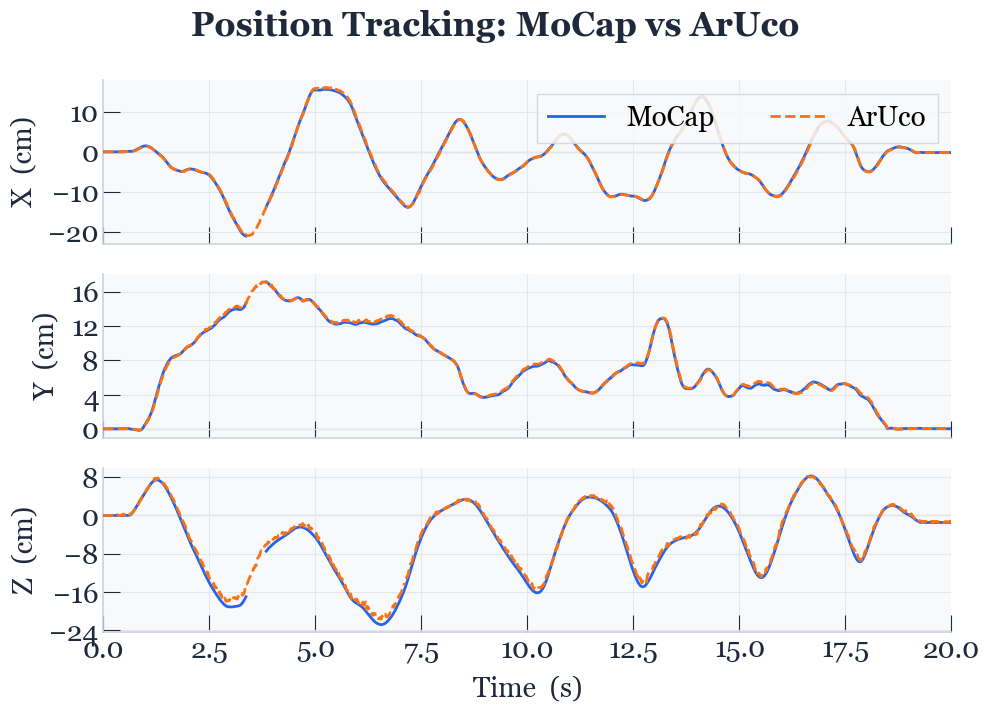

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Palette ────────────────────────────────────────────────────────────────────
MOCAP_COLOR  = "#2563EB"   # strong blue  → OptiTrack / mocap
ARUCO_COLOR  = "#F97316"   # vivid orange → ArUco marker
BG_COLOR     = "#F8F9FA"
GRID_COLOR   = "#E2E8F0"
SPINE_COLOR  = "#CBD5E1"
TEXT_COLOR   = "#1E293B"

# ── Global style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Georgia", "DejaVu Serif"],
    "axes.facecolor":     BG_COLOR,
    "figure.facecolor":   "white",
    "axes.edgecolor":     SPINE_COLOR,
    "axes.linewidth":     1.2,
    "axes.labelcolor":    TEXT_COLOR,
    "axes.labelsize":     20,
    "axes.titlesize":     20,
    "axes.titleweight":   "bold",
    "xtick.labelsize":    20,
    "ytick.labelsize":    20,
    "xtick.color":        TEXT_COLOR,
    "ytick.color":        TEXT_COLOR,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.major.size":   12,
    "ytick.major.size":   12,
    "legend.fontsize":    20,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   SPINE_COLOR,
    "legend.fancybox":    False,
    "grid.color":         GRID_COLOR,
    "grid.linewidth":     0.8,
    "lines.linewidth":    2.0,
    "lines.antialiased":  True,
})

# ── Data (replace with yours) ───────────────────────────────────────────────────
# mocap_df, ar_df, mt_dict, t_dict = ...

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.suptitle("Position Tracking: MoCap vs ArUco", fontsize=24,
             fontweight="bold", color=TEXT_COLOR, y=1.01)

time_offset = 3  # seconds to shift time axes for better visual alignment

axes_cfg = [
    ("X", mocap_df["time_sec"].to_numpy()-time_offset, np.array(mt_dict["x"])*100,
            ar_df["time_sec"].to_numpy()-time_offset,  np.array(t_dict["x"])*100,  None),
    ("Y", mocap_df["time_sec"].to_numpy()-time_offset, np.array(mt_dict["y"])*100,
            ar_df["time_sec"].to_numpy()-time_offset,  np.array(t_dict["y"])*100,  None),
    ("Z", mocap_df["time_sec"].to_numpy()-time_offset, np.array(mt_dict["z"])*100,
            ar_df["time_sec"].to_numpy()-time_offset,  np.array(t_dict["z"])*100,  (-17, 17)),
]

for ax, (axis_label, mt_t, mt_vals, ar_t, ar_vals, ylim) in zip(axes, axes_cfg):
    ax.plot(mt_t, mt_vals, color=MOCAP_COLOR,  label="MoCap",  zorder=3)
    ax.plot(ar_t, ar_vals, color=ARUCO_COLOR,  label="ArUco",  zorder=3, linestyle="--")

    ax.set_ylabel(f"{axis_label}  (cm)", labelpad=8)
    ax.set_xlim([0, 20])
    # if ylim:
    #     ax.set_ylim(ylim)

    ax.yaxis.set_major_locator(ticker.MaxNLocator(5, prune="both"))
    ax.grid(True, which="major", axis="both")
    ax.axhline(0, color=SPINE_COLOR, linewidth=1.0, zorder=1)

    # Remove top / right spines for a cleaner look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Shared legend (only on first subplot)
    if axis_label == "X":
        ax.legend(loc="upper right", ncol=2)

# Only the bottom subplot gets an x-label (sharex=True)
axes[-1].set_xlabel("Time  (s)", labelpad=8)

plt.tight_layout(h_pad=1.5)
plt.savefig("tracking_comparison.pdf", bbox_inches="tight", dpi=200)
plt.show()

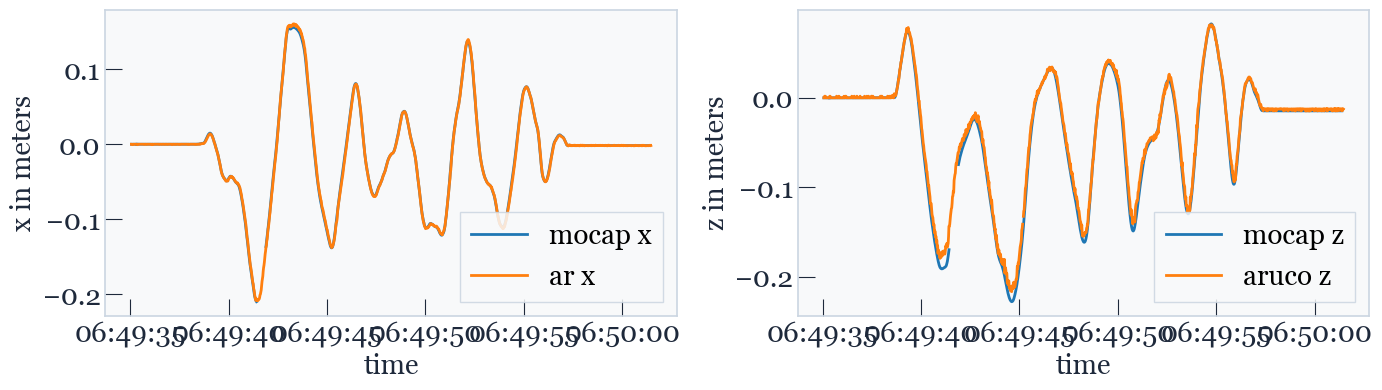

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(mocap_df["time"], mt_dict["x"], label="mocap x")
axes[0].plot(ar_df["time"], t_dict["x"], label="ar x")
axes[0].set_xlabel("time")
axes[0].set_ylabel("x in meters")
axes[0].legend()

axes[1].plot(mocap_df["time"], mt_dict["z"], label="mocap z")
axes[1].plot(ar_df["time"], np.array(t_dict["z"]), label="aruco z")
axes[1].set_xlabel("time")
axes[1].set_ylabel("z in meters")
axes[1].legend()

plt.tight_layout()
plt.show()

## Interpolation

In [25]:
mt_dict["time"] = mocap_df["time"]

In [26]:
mocap = pl.from_dict(mt_dict)

x1 = interp1d(mocap["time"].dt.epoch(), mocap["x"], fill_value="extrapolate")
y1 = interp1d(mocap["time"].dt.epoch(), mocap["y"], fill_value="extrapolate")
z1 = interp1d(mocap["time"].dt.epoch(), mocap["z"], fill_value="extrapolate")

mocap_ip = {"time": ar_df["time"]}
mocap_ip["x"] = x1(ar_df["time"].dt.epoch())
mocap_ip["y"] = y1(ar_df["time"].dt.epoch())
mocap_ip["z"] = z1(ar_df["time"].dt.epoch())
mocap_ip = pl.from_dict(mocap_ip)

In [27]:
_err_x = np.nanmean(abs(mocap_ip["x"] - np.array(t_dict["x"])))
_err_y = np.nanmean(abs(mocap_ip["y"] - np.array(t_dict["y"])))
_err_z = np.nanmean(abs(mocap_ip["z"] - np.array(t_dict["z"])))

_max_x = np.nanmax(abs(mocap_ip["x"] - np.array(t_dict["x"])))
_max_y = np.nanmax(abs(mocap_ip["y"] - np.array(t_dict["y"])))
_max_z = np.nanmax(abs(mocap_ip["z"] - np.array(t_dict["z"])))

_sd_x = np.nanstd(abs(mocap_ip["x"] - np.array(t_dict["x"])).to_numpy())
_sd_y = np.nanstd(abs(mocap_ip["y"] - np.array(t_dict["y"])).to_numpy())
_sd_z = np.nanstd(abs(mocap_ip["z"] - np.array(t_dict["z"])).to_numpy())

In [28]:
print(_sd_x * 100, _sd_y * 100, _sd_z * 100)

0.13458445982054845 0.09210676500634965 0.44107895482966053


In [29]:
print(_err_x * 100, _err_y * 100, _err_z * 100)

0.11059780432237531 0.08772036032114884 0.4322914365853926


In [30]:
print(_max_x * 100, _max_y * 100, _max_z * 100)

0.6431786416634961 0.40388984734150424 2.6922093623158947


Angle

In [31]:
rvecs = ar_df[["rx", "ry", "rz"]].to_numpy()

# ── 1. Find valid rows (no NaN / Inf) ──────────────────────────────────────
valid_mask = np.isfinite(rvecs).all(axis=1)
rvecs_clean = rvecs[valid_mask]

# ── 2. Build rotation matrices only on clean data ───────────────────────────
rmats = R.from_rotvec(rvecs_clean).as_matrix()

# ── 3. Relative rotation w.r.t. first valid frame ──────────────────────────
rotation = np.array([_r.T @ rmats[0] for _r in rmats])

# ── 4. Convert to Euler ─────────────────────────────────────────────────────
euler_ar = R.from_matrix(rotation).as_euler("ZYX", degrees=True)

# ── 5. Reconstruct full-length array with NaN where detection failed ────────
euler_ar_full = np.full((len(rvecs), 3), np.nan)
euler_ar_full[valid_mask] = euler_ar

In [32]:
euler_ar_full

array([[ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.66512818,  2.03000438, -5.67006361],
       ...,
       [ 0.27982911, -4.87723058, -0.89853561],
       [ 1.59947267, 13.83109511,  5.54892164],
       [ 1.18489901, 11.75040422,  3.97893482]], shape=(1293, 3))

In [33]:
ar_time = ar_df["time_sec"].to_numpy() - 5

In [34]:
# rvecs = ar_df[["rx", "ry", "rz"]].to_numpy()
# rmats = R.from_rotvec(rvecs).as_matrix()
# rotation = np.array([_r.T @ rmats[0] for _r in rmats])
# euler_ar = R.from_matrix(rotation).as_euler("ZYX", degrees=True)

In [35]:
# plt.plot(euler_ar)

In [36]:
mocap_qts = mocap_df[["rb_ang_x", "rb_ang_y", "rb_ang_z", "rb_ang_w"]].to_numpy()

mocap_rmats = []
for _q in mocap_qts:
    try:
        mocap_rmats.append(R.from_quat(_q).as_matrix())
    except:
        mocap_rmats.append(np.eye(3))
# mocap_rmats = R.from_quat(mocap_qts).as_matrix()

In [37]:
mocap_ang = [_r.T @ mocap_rmats[0] for _r in mocap_rmats]
mocap_euler = R.from_matrix(mocap_ang).as_euler("zyx", degrees=True)

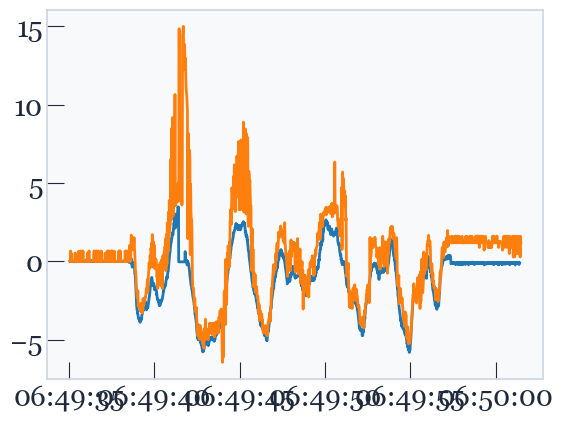

In [38]:
plt.plot(mocap_df["time"], mocap_euler[:, 0])
plt.plot(ar_df["time"], euler_ar_full[:, 0])

C:\Users\Pintu\AppData\Local\Temp\ipykernel_29804\177704965.py:129: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\Pintu\AppData\Local\Temp\ipykernel_29804\177704965.py:129: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


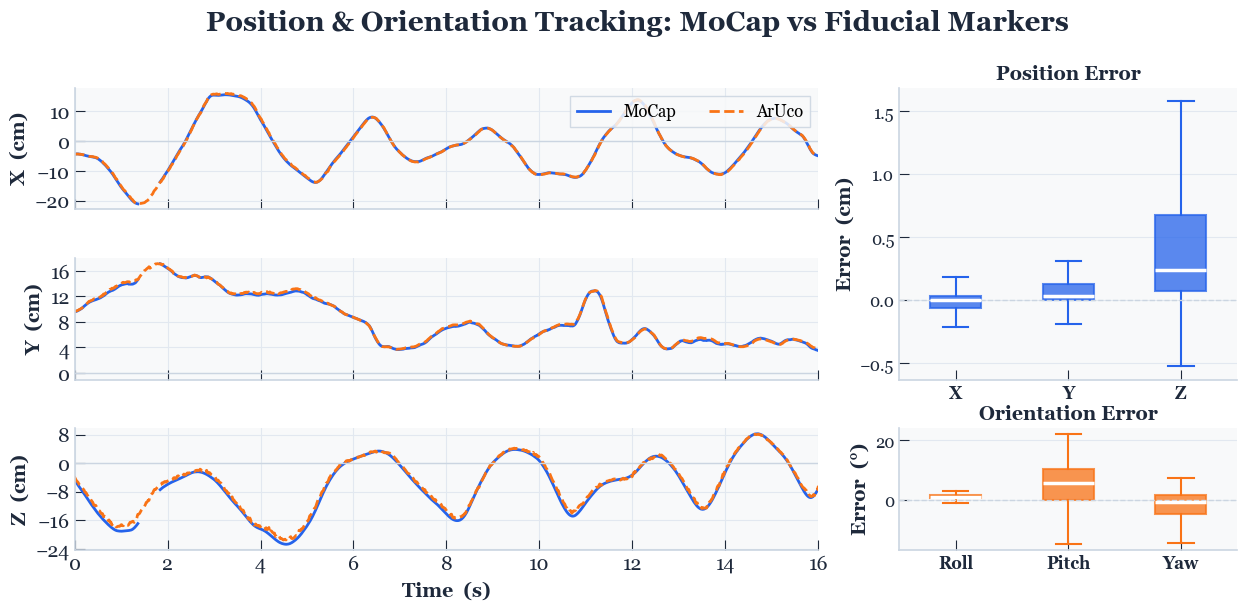

In [51]:
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import numpy as np
from scipy.interpolate import interp1d

# ── Colours ────────────────────────────────────────────────────────────────
MOCAP_COLOR = "#2563EB"
ARUCO_COLOR = "#F97316"
BG_COLOR    = "#F8F9FA"
GRID_COLOR  = "#E2E8F0"
SPINE_COLOR = "#CBD5E1"
TEXT_COLOR  = "#1E293B"

# ── Global style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Georgia", "DejaVu Serif"],
    "axes.facecolor":    BG_COLOR,
    "figure.facecolor":  "white",
    "axes.edgecolor":    SPINE_COLOR,
    "axes.linewidth":    1.2,
    "axes.labelcolor":   TEXT_COLOR,
    "axes.labelsize":    14,
    "axes.titlesize":    14,
    "axes.titleweight":  "bold",
    "xtick.labelsize":   12,
    "ytick.labelsize":   12,
    "xtick.color":       TEXT_COLOR,
    "ytick.color":       TEXT_COLOR,
    "xtick.direction":   "in",
    "ytick.direction":   "in",
    "xtick.major.size":  7,
    "ytick.major.size":  7,
    "legend.fontsize":   12,
    "legend.framealpha": 0.85,
    "legend.edgecolor":  SPINE_COLOR,
    "legend.fancybox":   False,
    "grid.color":        GRID_COLOR,
    "grid.linewidth":    0.8,
    "lines.linewidth":   2.0,
    "lines.antialiased": True,
})

# ── Interpolation helper ───────────────────────────────────────────────────
def interp_to(source_t, source_v, target_t):
    """Interpolate source onto target timeline, NaN outside range."""
    f = interp1d(source_t, source_v, axis=0, bounds_error=False, fill_value=np.nan)
    return f(target_t)

# ── Time arrays (must be float seconds) ───────────────────────────────────
mocap_t = mocap_df["time_sec"].to_numpy()
ar_t    = ar_df["time_sec"].to_numpy()

# ── Position data (cm) ─────────────────────────────────────────────────────
mocap_pos = np.column_stack([
    np.array(mt_dict["x"]) * 100,
    np.array(mt_dict["y"]) * 100,
    np.array(mt_dict["z"]) * 100,
])
ar_pos_interp = interp_to(
    ar_t,
    np.column_stack([
        np.array(t_dict["x"]) * 100,
        np.array(t_dict["y"]) * 100,
        np.array(t_dict["z"]) * 100,
    ]),
    mocap_t,
)
pos_error = ar_pos_interp - mocap_pos

# ── Orientation data (degrees) ─────────────────────────────────────────────
ar_euler_interp = interp_to(ar_t, euler_ar_full, mocap_t)
ori_error       = ar_euler_interp - mocap_euler

# ── Clean NaNs for boxplots ────────────────────────────────────────────────
pos_err_clean = pos_error[np.isfinite(pos_error).all(axis=1)]
ori_err_clean = ori_error[np.isfinite(ori_error).all(axis=1)]

# ── Figure & GridSpec ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 6))
gs = gridspec.GridSpec(
    3, 2,
    width_ratios=[2.2, 1],
    hspace=0.4,       # was 0.25
    wspace=0.15,       # was 0.28
)

ax_x   = fig.add_subplot(gs[0, 0])
ax_y   = fig.add_subplot(gs[1, 0], sharex=ax_x)
ax_z   = fig.add_subplot(gs[2, 0], sharex=ax_x)
ax_pos = fig.add_subplot(gs[0:2, 1])
ax_ori = fig.add_subplot(gs[2, 1])

fig.suptitle("Position & Orientation Tracking: MoCap vs Fiducial Markers",
             fontsize=20, fontweight="bold", color=TEXT_COLOR, y=1.01)

# ── Time-series (left column) ──────────────────────────────────────────────
ts_cfg = [
    (ax_x, "X  (cm)", mocap_pos[:, 0], ar_pos_interp[:, 0]),
    (ax_y, "Y  (cm)", mocap_pos[:, 1], ar_pos_interp[:, 1]),
    (ax_z, "Z  (cm)", mocap_pos[:, 2], ar_pos_interp[:, 2]),
]

for ax, lbl, mocap_vals, ar_vals in ts_cfg:
    ax.plot(mocap_t - 5, mocap_vals, color=MOCAP_COLOR, lw=2, label="MoCap")
    ax.plot(mocap_t - 5, ar_vals,    color=ARUCO_COLOR, lw=2,
            linestyle="--", label="ArUco")
    ax.set_ylabel(lbl, fontsize=14, fontweight="bold", color=TEXT_COLOR)
    ax.set_xlim([0, 16])
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5, prune="both"))
    ax.grid(True, color=GRID_COLOR, linewidth=0.8)
    ax.axhline(0, color=SPINE_COLOR, lw=1.0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=14)

# x-label only on bottom panel
plt.setp(ax_x.get_xticklabels(), visible=False)
plt.setp(ax_y.get_xticklabels(), visible=False)
ax_z.set_xlabel("Time  (s)", labelpad=6, fontsize=14, fontweight="bold")

# Legend inside top-left panel
ax_x.legend(loc="upper right", ncol=2, fontsize=12,
            framealpha=0.85, edgecolor=SPINE_COLOR, fancybox=False)

# ── Boxplot helper ─────────────────────────────────────────────────────────
def styled_boxplot(ax, data_cols, labels, title, ylabel, color):

    bp = ax.boxplot(
        [col[np.isfinite(col)] for col in data_cols],
        labels=labels,
        patch_artist=True,
        widths=0.45,
        showfliers=False,          # ← add this
        medianprops=dict(color="white", linewidth=2.5),
        whiskerprops=dict(color=color, linewidth=1.5),
        capprops=dict(color=color, linewidth=1.5),

    )
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
        patch.set_linewidth(1.5)
        patch.set_edgecolor(color)

    ax.axhline(0, color=SPINE_COLOR, lw=1.0, linestyle="--")
    ax.set_title(title, fontsize=14, fontweight="bold", color=TEXT_COLOR, pad=6)
    ax.set_ylabel(ylabel, fontsize=14, fontweight="bold", color=TEXT_COLOR)
    ax.grid(True, axis="y", color=GRID_COLOR, linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=12)

    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
    
styled_boxplot(
    ax_pos,
    data_cols=[pos_err_clean[:, 0], pos_err_clean[:, 1], pos_err_clean[:, 2]],
    labels=["X", "Y", "Z"],
    title="Position Error",
    ylabel="Error  (cm)",
    color=MOCAP_COLOR,
)

styled_boxplot(
    ax_ori,
    data_cols=[ori_err_clean[:, 0], ori_err_clean[:, 1], ori_err_clean[:, 2]],
    labels=["Roll", "Pitch", "Yaw"],
    title="Orientation Error",
    ylabel="Error  (°)",
    color=ARUCO_COLOR,
)

plt.savefig("tracking_full.pdf", dpi=200)
plt.show()

In [54]:
# ── Error Statistics ───────────────────────────────────────────────────────
def print_error_stats(data, axis_labels, section_title):
    print(f"\n{'═'*50}")
    print(f"  {section_title}")
    print(f"{'═'*50}")
    header = f"{'Axis':<10} {'Mean':>10} {'MAE':>10} {'Max Abs':>10} {'SD':>10} {'RMSE':>10}"
    print(header)
    print(f"{'─'*60}")
    for i, lbl in enumerate(axis_labels):
        col = data[:, i]
        col = col[np.isfinite(col)]
        mean    = np.mean(col)
        mae     = np.mean(np.abs(col))
        max_abs = np.max(np.abs(col))
        sd      = np.std(col, ddof=1)
        rmse    = np.sqrt(np.mean(col**2))
        print(f"{lbl:<10} {mean:>+10.4f} {mae:>10.4f} {max_abs:>10.4f} {sd:>10.4f} {rmse:>10.4f}")

print_error_stats(pos_err_clean, ["X", "Y", "Z"],          "Position Error  (cm)")
print_error_stats(ori_err_clean, ["Roll", "Pitch", "Yaw"], "Orientation Error  (°)")


══════════════════════════════════════════════════
  Position Error  (cm)
══════════════════════════════════════════════════
Axis             Mean        MAE    Max Abs         SD       RMSE
────────────────────────────────────────────────────────────
X             +0.0030     0.1093     0.6391     0.1713     0.1713
Y             +0.0569     0.0874     0.3982     0.1126     0.1262
Z             +0.4107     0.4305     2.6211     0.4532     0.6115

══════════════════════════════════════════════════
  Orientation Error  (°)
══════════════════════════════════════════════════
Axis             Mean        MAE    Max Abs         SD       RMSE
────────────────────────────────────────────────────────────
Roll          +1.2420     1.2760    15.0231     1.6974     2.1030
Pitch         +3.2176     7.7572    39.0644     9.2608     9.8021
Yaw           -3.5509     5.4786    42.1440     8.5992     9.3020


In [69]:
from scipy import stats

# ── CONFIG: change this to whatever percentile you want ───────────────────
PERCENTILE = 95   # e.g. 90, 95, 99

# ── Z-score filter ─────────────────────────────────────────────────────────
def clip_zscore(arr, percentile):
    """Keep rows where z-score of every column is within the given percentile."""
    z_threshold = stats.norm.ppf((1 + percentile / 100) / 2)  # two-tailed
    z_scores = np.abs(stats.zscore(arr, nan_policy="omit"))
    mask = (z_scores < z_threshold).all(axis=1)
    return arr[mask]

pos_err_z = clip_zscore(pos_err_clean, PERCENTILE)
ori_err_z = clip_zscore(ori_err_clean, PERCENTILE)

# ── Print stats ────────────────────────────────────────────────────────────
print(f"=== Position Error (z-score ≤ {PERCENTILE}th percentile) ===")
for i, axis in enumerate(["X", "Y", "Z"]):
    col = pos_err_z[:, i]
    print(f"  {axis}: mean={np.abs(col).mean():.3f} cm  std={col.std():.3f} cm  "
          f"RMSE={np.sqrt((col**2).mean()):.3f} cm  MAE={np.abs(col).max():.3f} cm")

print(f"\n=== Orientation Error (z-score ≤ {PERCENTILE}th percentile) ===")
for i, axis in enumerate(["Roll", "Pitch", "Yaw"]):
    col = ori_err_z[:, i]
    print(f"  {axis}: mean={np.abs(col).mean():.3f}°  std={col.std():.3f}°  "
          f"RMSE={np.sqrt((col**2).mean()):.3f}°  MAE={np.abs(col).max():.3f}°")

=== Position Error (z-score ≤ 95th percentile) ===
  X: mean=0.070 cm  std=0.105 cm  RMSE=0.109 cm  MAE=0.338 cm
  Y: mean=0.063 cm  std=0.083 cm  RMSE=0.092 cm  MAE=0.276 cm
  Z: mean=0.342 cm  std=0.354 cm  RMSE=0.479 cm  MAE=1.298 cm

=== Orientation Error (z-score ≤ 95th percentile) ===
  Roll: mean=0.924°  std=0.724°  RMSE=1.152°  MAE=4.554°
  Pitch: mean=6.752°  std=6.146°  RMSE=8.005°  MAE=18.917°
  Yaw: mean=3.723°  std=5.380°  RMSE=5.616°  MAE=20.382°


In [60]:
def clip_iqr(arr):
    """Filter rows to within boxplot whisker range (Q1 - 1.5·IQR, Q3 + 1.5·IQR) per column."""
    mask = np.ones(len(arr), dtype=bool)
    for i in range(arr.shape[1]):
        col = arr[:, i]
        q1, q3 = np.percentile(col, 25), np.percentile(col, 75)
        iqr = q3 - q1
        mask &= (col >= q1 - 1.5 * iqr) & (col <= q3 + 1.5 * iqr)
    return arr[mask]

pos_err_iqr = clip_iqr(pos_err_clean)
ori_err_iqr = clip_iqr(ori_err_clean)

# ── Print stats ────────────────────────────────────────────────────────────
print("=== Position Error (boxplot whisker range, 1.5×IQR) ===")
for i, axis in enumerate(["X", "Y", "Z"]):
    col = pos_err_iqr[:, i]
    print(f"  {axis}: mean={col.mean():.3f} cm  std={col.std():.3f} cm  "
          f"RMSE={np.sqrt((col**2).mean()):.3f} cm  "
          f"MAE={np.abs(col).mean():.3f} cm")

print("\n=== Orientation Error (boxplot whisker range, 1.5×IQR) ===")
for i, axis in enumerate(["Roll", "Pitch", "Yaw"]):
    col = ori_err_iqr[:, i]
    print(f"  {axis}: mean={col.mean():.3f}°  std={col.std():.3f}°  "
          f"RMSE={np.sqrt((col**2).mean()):.3f}°  "
          f"MAE={np.abs(col).mean():.3f}°")

=== Position Error (boxplot whisker range, 1.5×IQR) ===
  X: mean=-0.021 cm  std=0.067 cm  RMSE=0.070 cm  MAE=0.048 cm
  Y: mean=0.043 cm  std=0.085 cm  RMSE=0.095 cm  MAE=0.065 cm
  Z: mean=0.328 cm  std=0.365 cm  RMSE=0.491 cm  MAE=0.345 cm

=== Orientation Error (boxplot whisker range, 1.5×IQR) ===
  Roll: mean=0.835°  std=0.602°  RMSE=1.029°  MAE=0.856°
  Pitch: mean=5.594°  std=5.678°  RMSE=7.971°  MAE=6.689°
  Yaw: mean=-0.907°  std=4.296°  RMSE=4.391°  MAE=3.127°


In [61]:
print("\n=== Orientation Error (boxplot whisker range, 1.5×IQR) ===")
for i, axis in enumerate(["Roll", "Pitch", "Yaw"]):
    col = ori_err_iqr[:, i]
    q1, med, q3 = np.percentile(col, [25, 50, 75])
    iqr = q3 - q1
    print(f"  {axis}:")
    print(f"    Q1={q1:.2f}°  Median={med:.2f}°  Q3={q3:.2f}°  IQR={iqr:.2f}°")
    print(f"    Whisker min={q1 - 1.5*iqr:.2f}°  max={q3 + 1.5*iqr:.2f}°")
    print(f"    mean={col.mean():.3f}°  std={col.std():.3f}°  "
          f"RMSE={np.sqrt((col**2).mean()):.3f}°  MAE={np.abs(col).mean():.3f}°")


=== Orientation Error (boxplot whisker range, 1.5×IQR) ===
  Roll:
    Q1=0.35°  Median=0.85°  Q3=1.30°  IQR=0.95°
    Whisker min=-1.07°  max=2.72°
    mean=0.835°  std=0.602°  RMSE=1.029°  MAE=0.856°
  Pitch:
    Q1=0.49°  Median=6.87°  Q3=10.29°  IQR=9.81°
    Whisker min=-14.22°  max=25.00°
    mean=5.594°  std=5.678°  RMSE=7.971°  MAE=6.689°
  Yaw:
    Q1=-2.66°  Median=-0.06°  Q3=2.00°  IQR=4.65°
    Whisker min=-9.64°  max=8.98°
    mean=-0.907°  std=4.296°  RMSE=4.391°  MAE=3.127°


ValueError: x and y must have same first dimension, but have shapes (1293,) and (1292,)

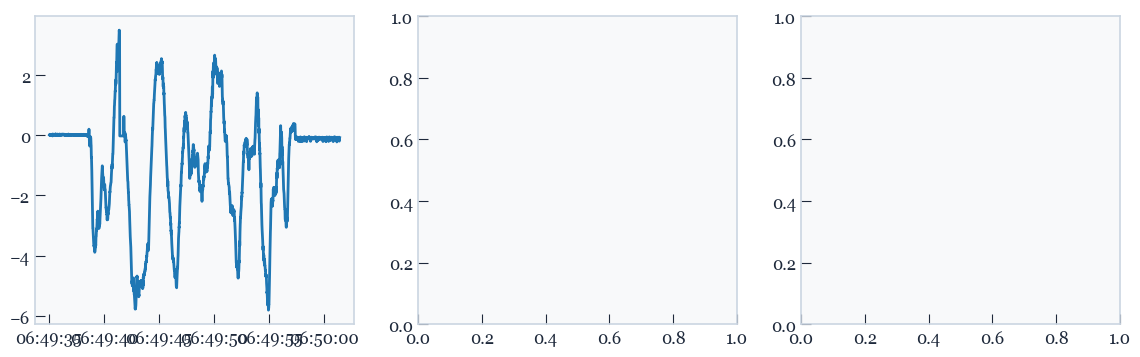

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(mocap_df["time"], mocap_euler[:, 0], label="mocap rx")
axes[0].plot(ar_df["time"], euler_ar[:, 0], label="ar rx")
axes[0].set_xlabel("time")
axes[0].set_ylabel("degrees")
axes[0].legend()

axes[1].plot(mocap_df["time"], mocap_euler[:, 1], label="mocap ry")
axes[1].plot(ar_df["time"], euler_ar[:, 1], label="aruco ry")
axes[1].set_xlabel("time")
axes[1].set_ylabel("degrees")
axes[1].legend()

axes[2].plot(mocap_df["time"], mocap_euler[:, 1], label="mocap rz")
axes[2].plot(ar_df["time"], euler_ar[:, 1], label="aruco rz")
axes[2].set_xlabel("time")
axes[2].set_ylabel("degrees")
axes[2].legend()


# axes[2].set_ylim([-0.01, 0.01])

plt.tight_layout()
plt.show()